In [ ]:
!pip -q install pymatgen mp-api spglib

import os
import json
import warnings
import sys

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymatgen.core import Lattice, Structure, Molecule
from pymatgen.core.surface import SlabGenerator
from pymatgen.core.composition import Composition
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.analysis.phase_diagram import PDEntry, PhaseDiagram
from pymatgen.transformations.standard_transformations import (
    SupercellTransformation,
    OrderDisorderedStructureTransformation,
    OxidationStateDecorationTransformation,
)
from pymatgen.io.cif import CifWriter

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

try:
    import pymatgen
    print("pymatgen:", pymatgen.__version__)
except Exception:
    import importlib.metadata
    print("pymatgen:", importlib.metadata.version("pymatgen"))

def line():
    print("=" * 100)

def header(title):
    line()
    print(title)
    line()

header("1. BUILD EXAMPLE STRUCTURES")

si = Structure(
    Lattice.cubic(5.431),
    ["Si", "Si"],
    [[0, 0, 0], [0.25, 0.25, 0.25]],
)

nacl = Structure(
    Lattice.cubic(5.64),
    ["Na", "Cl"],
    [[0, 0, 0], [0.5, 0.5, 0.5]],
)

li_fe_po4 = Structure(
    Lattice.orthorhombic(10.33, 6.01, 4.69),
    ["Li", "Fe", "P", "O", "O", "O", "O"],
    [
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.5],
        [0.1, 0.25, 0.2],
        [0.22, 0.04, 0.28],
        [0.72, 0.54, 0.78],
        [0.31, 0.66, 0.12],
        [0.81, 0.16, 0.62],
    ],
)

for name, s in [("Si", si), ("NaCl", nacl), ("LiFePO4-like", li_fe_po4)]:
    print(f"{name}: formula={s.composition.formula}, sites={len(s)}, volume={s.volume:.3f} Å^3")

In [ ]:
header("2. BASIC INTROSPECTION")

for name, s in [("Si", si), ("NaCl", nacl), ("LiFePO4-like", li_fe_po4)]:
    print(f"\n{name}")
    print("Reduced formula:", s.composition.reduced_formula)
    print("Density:", round(s.density, 4), "g/cm^3")
    print("Lattice parameters (a, b, c):", tuple(round(x, 4) for x in s.lattice.abc))
    print("Angles (alpha, beta, gamma):", tuple(round(x, 4) for x in s.lattice.angles))
    print("First site:", s[0])

header("3. SPACE GROUP AND SYMMETRY ANALYSIS")

for name, s in [("Si", si), ("NaCl", nacl), ("LiFePO4-like", li_fe_po4)]:
    sga = SpacegroupAnalyzer(s, symprec=0.1)
    print(f"\n{name}")
    print("Space group symbol:", sga.get_space_group_symbol())
    print("Space group number:", sga.get_space_group_number())
    print("Crystal system:", sga.get_crystal_system())
    print("Lattice type:", sga.get_lattice_type())
    print("Primitive sites:", len(sga.find_primitive()))
    print("Conventional sites:", len(sga.get_conventional_standard_structure()))

In [ ]:
header("4. LOCAL ENVIRONMENT WITH CRYSTALNN")

cnn = CrystalNN()

def summarize_neighbors(structure, label):
    print(f"\n{label}")
    for i, site in enumerate(structure[:min(4, len(structure))]):
        try:
            nn_info = cnn.get_nn_info(structure, i)
            species = [str(x["site"].specie) for x in nn_info]
            weights = [round(float(x["weight"]), 3) for x in nn_info]
            print(f"Site {i} {site.species_string}: CN={len(nn_info)}, neighbors={species}, weights={weights}")
        except Exception as e:
            print(f"Site {i} {site.species_string}: neighbor analysis failed -> {e}")

summarize_neighbors(si, "Si")
summarize_neighbors(nacl, "NaCl")

header("5. OXIDATION STATE DECORATION")

oxi_transform = OxidationStateDecorationTransformation(
    {"Li": 1, "Fe": 2, "P": 5, "O": -2, "Na": 1, "Cl": -1, "Si": 0}
)

nacl_oxi = oxi_transform.apply_transformation(nacl.copy())
lfp_oxi = oxi_transform.apply_transformation(li_fe_po4.copy())

print("NaCl species with oxidation states:", [str(site.specie) for site in nacl_oxi])
print("LiFePO4-like species with oxidation states:", [str(site.specie) for site in lfp_oxi])

In [ ]:
header("6. MAKE SUPERCELLS")

si_super = SupercellTransformation([[2, 0, 0], [0, 2, 0], [0, 0, 2]]).apply_transformation(si.copy())
nacl_super = SupercellTransformation([[2, 0, 0], [0, 2, 0], [0, 0, 2]]).apply_transformation(nacl.copy())

print("Si supercell sites:", len(si_super), "formula:", si_super.composition.formula)
print("NaCl supercell sites:", len(nacl_super), "formula:", nacl_super.composition.formula)

header("7. PERTURB STRUCTURE AND COMPUTE DISTANCE MATRIX")

si_perturbed = si_super.copy()
si_perturbed.translate_sites([0], [0.01, -0.005, 0.012], frac_coords=False)

dm = si_perturbed.distance_matrix

print("Distance matrix shape:", dm.shape)
print("First 5 distances from site 0:", np.round(dm[0][:5], 4))

header("8. GENERATE A SURFACE SLAB")

slabgen = SlabGenerator(
    initial_structure=si,
    miller_index=(1, 1, 1),
    min_slab_size=8.0,
    min_vacuum_size=12.0,
    center_slab=True,
    in_unit_planes=False,
)

slabs = slabgen.get_slabs()
slab = slabs[0]

print("Number of generated slabs:", len(slabs))
print("Chosen slab formula:", slab.composition.formula)
print("Chosen slab sites:", len(slab))
print("Chosen slab lattice:", tuple(round(x, 3) for x in slab.lattice.abc))

In [ ]:
header("9. XRD SIMULATION")

xrd = XRDCalculator(wavelength="CuKa")

pattern_si = xrd.get_pattern(si, two_theta_range=(10, 90))
pattern_nacl = xrd.get_pattern(nacl, two_theta_range=(10, 90))

plt.figure(figsize=(12, 4))
plt.vlines(pattern_si.x, [0], pattern_si.y, linewidth=1.5)
plt.xlabel(r"2$\theta$ (degrees)")
plt.ylabel("Intensity")
plt.title("Simulated XRD Pattern: Si")
plt.show()

plt.figure(figsize=(12, 4))
plt.vlines(pattern_nacl.x, [0], pattern_nacl.y, linewidth=1.5)
plt.xlabel(r"2$\theta$ (degrees)")
plt.ylabel("Intensity")
plt.title("Simulated XRD Pattern: NaCl")
plt.show()

header("10. SIMPLE PHASE DIAGRAM")

entries = [
    PDEntry(Composition("Li"), 0.0),
    PDEntry(Composition("Fe"), 0.0),
    PDEntry(Composition("P"), 0.0),
    PDEntry(Composition("O2"), 0.0),
    PDEntry(Composition("Li2O"), -6.0),
    PDEntry(Composition("FeO"), -4.2),
    PDEntry(Composition("Fe2O3"), -10.5),
    PDEntry(Composition("P2O5"), -15.0),
    PDEntry(Composition("Li3PO4"), -18.5),
    PDEntry(Composition("FePO4"), -12.2),
    PDEntry(Composition("LiFePO4"), -16.9),
]

pdg = PhaseDiagram(entries)

target = [e for e in entries if e.composition.reduced_formula == "LiFePO4"][0]

e_above_hull = pdg.get_e_above_hull(target)
decomp, e_hull = pdg.get_decomp_and_e_above_hull(target)

print("Target entry:", target.composition.reduced_formula)
print("Energy above hull:", round(float(e_above_hull), 6), "eV/atom")

print("Decomposition products:")
for k, v in decomp.items():
    print(" ", k.composition.reduced_formula, ":", round(float(v), 6))

Python: 3.12.12
NumPy: 2.0.2
pandas: 2.2.2
pymatgen: 2025.10.7
1. BUILD EXAMPLE STRUCTURES
Si: formula=Si2, sites=2, volume=160.191 Å^3
NaCl: formula=Na1 Cl1, sites=2, volume=179.406 Å^3
LiFePO4-like: formula=Li1 Fe1 P1 O4, sites=7, volume=291.171 Å^3
2. BASIC INTROSPECTION

Si
Reduced formula: Si
Density: 0.5823 g/cm^3
Lattice parameters (a, b, c): (5.431, 5.431, 5.431)
Angles (alpha, beta, gamma): (90.0, 90.0, 90.0)
First site: [0. 0. 0.] Si

NaCl
Reduced formula: NaCl
Density: 0.5409 g/cm^3
Lattice parameters (a, b, c): (5.64, 5.64, 5.64)
Angles (alpha, beta, gamma): (90.0, 90.0, 90.0)
First site: [0. 0. 0.] Na

LiFePO4-like
Reduced formula: LiFePO4
Density: 0.8997 g/cm^3
Lattice parameters (a, b, c): (10.33, 6.01, 4.69)
Angles (alpha, beta, gamma): (90.0, 90.0, 90.0)
First site: [0. 0. 0.] Li
3. SPACE GROUP AND SYMMETRY ANALYSIS

Si
Space group symbol: R-3m
Space group number: 166
Crystal system: trigonal
Lattice type: rhombohedral
Primitive sites: 2
Conventional sites: 6

NaCl
Spa

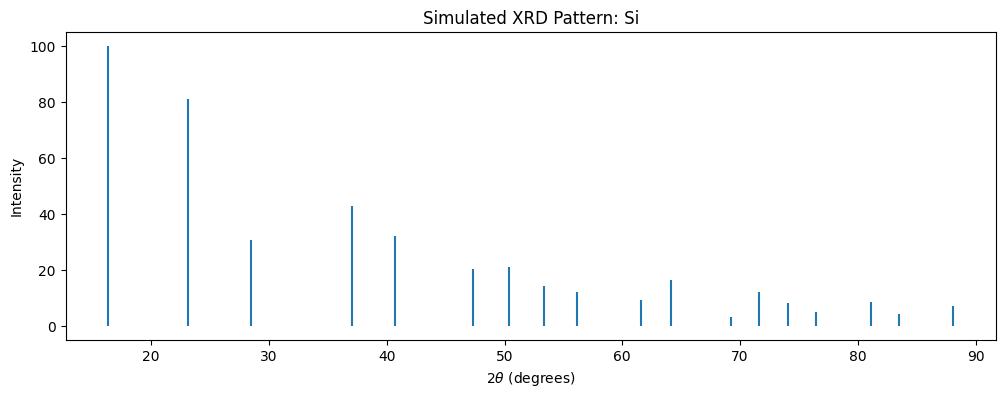

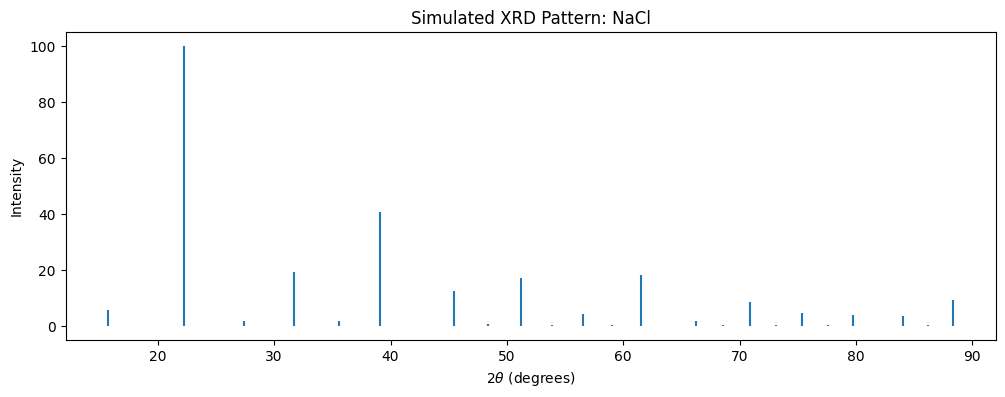

10. SIMPLE PHASE DIAGRAM
Target entry: LiFePO4
Energy above hull: 0.0 eV/atom
Decomposition products:
  LiFePO4 : 1.0
11. DISORDERED STRUCTURE -> ORDERED APPROXIMATION
Disordered composition: Cu4 Au4
Ordered candidate 1: formula=Cu4 Au4, sites=8
Ordered candidate 2: formula=Cu4 Au4, sites=8
Ordered candidate 3: formula=Cu4 Au4, sites=8
12. MOLECULE SUPPORT
Water formula: H2 O1
Water center of mass: [0.     0.     0.0564]
O-H bond lengths: 0.9109 0.9109
13. CIF EXPORT
Saved: /content/pymatgen_tutorial_outputs/si.cif
Saved: /content/pymatgen_tutorial_outputs/nacl.cif
Saved: /content/pymatgen_tutorial_outputs/si_111_slab.cif
14. DATAFRAME SUMMARY
           name  formula  sites  volume_A3  density_g_cm3 spacegroup  \
0            Si       Si      2   160.1915         0.5823       R-3m   
1          NaCl     NaCl      2   179.4061         0.5409      Pm-3m   
2  LiFePO4-like  LiFePO4      7   291.1707         0.8997         P1   
3       Si slab       Si      6  1121.3403         0.2495   

In [2]:
header("11. DISORDERED STRUCTURE -> ORDERED APPROXIMATION")

disordered = Structure(
    Lattice.cubic(3.6),
    [{"Cu": 0.5, "Au": 0.5}],
    [[0, 0, 0]],
)

disordered.make_supercell([2, 2, 2])

print("Disordered composition:", disordered.composition)

try:
    disordered_oxi = disordered.copy()
    disordered_oxi.add_oxidation_state_by_element({"Cu": 1, "Au": 1})

    ordered_transform = OrderDisorderedStructureTransformation()

    ordered_candidates = ordered_transform.apply_transformation(
        disordered_oxi,
        return_ranked_list=3,
    )

    for idx, cand in enumerate(ordered_candidates):
        s = cand["structure"].copy()
        s.remove_oxidation_states()
        print(f"Ordered candidate {idx+1}: formula={s.composition.formula}, sites={len(s)}")

except Exception as e:
    print("Ordering step skipped due to transformation issue:", e)

header("12. MOLECULE SUPPORT")

water = Molecule(
    ["O", "H", "H"],
    [
        [0.0, 0.0, 0.0],
        [0.7586, 0.0, 0.5043],
        [-0.7586, 0.0, 0.5043],
    ],
)

print("Water formula:", water.composition.formula)

print("Water center of mass:", np.round(water.center_of_mass, 4))

print(
    "O-H bond lengths:",
    round(water.get_distance(0, 1), 4),
    round(water.get_distance(0, 2), 4),
)

header("13. CIF EXPORT")

output_dir = "/content/pymatgen_tutorial_outputs"

os.makedirs(output_dir, exist_ok=True)

si_cif = os.path.join(output_dir, "si.cif")
nacl_cif = os.path.join(output_dir, "nacl.cif")
slab_cif = os.path.join(output_dir, "si_111_slab.cif")

CifWriter(si).write_file(si_cif)
CifWriter(nacl).write_file(nacl_cif)
CifWriter(slab).write_file(slab_cif)

print("Saved:", si_cif)
print("Saved:", nacl_cif)
print("Saved:", slab_cif)

header("14. DATAFRAME SUMMARY")

rows = []

for name, s in [
    ("Si", si),
    ("NaCl", nacl),
    ("LiFePO4-like", li_fe_po4),
    ("Si slab", slab),
]:

    sga = SpacegroupAnalyzer(s, symprec=0.1)

    rows.append(
        {
            "name": name,
            "formula": s.composition.reduced_formula,
            "sites": len(s),
            "volume_A3": round(s.volume, 4),
            "density_g_cm3": round(float(s.density), 4),
            "spacegroup": sga.get_space_group_symbol(),
            "sg_number": sga.get_space_group_number(),
        }
    )

df = pd.DataFrame(rows)

print(df)

header("15. OPTIONAL MATERIALS PROJECT API ACCESS")

mp_api_key = None

try:
    from google.colab import userdata
    mp_api_key = userdata.get("MP_API_KEY")
except Exception:
    pass

if not mp_api_key:
    mp_api_key = os.environ.get("MP_API_KEY", None)

if mp_api_key:

    try:
        from pymatgen.ext.matproj import MPRester

        with MPRester(mp_api_key) as mpr:

            mp_struct = mpr.get_structure_by_material_id("mp-149")

            summary_docs = mpr.summary.search(
                material_ids=["mp-149"],
                fields=[
                    "material_id",
                    "formula_pretty",
                    "band_gap",
                    "energy_above_hull",
                    "is_stable",
                ],
            )

        print("Fetched mp-149 from Materials Project")

        print("Formula:", mp_struct.composition.reduced_formula)

        print("Sites:", len(mp_struct))

        if len(summary_docs) > 0:

            doc = summary_docs[0]

            print(
                {
                    "material_id": str(doc.material_id),
                    "formula_pretty": doc.formula_pretty,
                    "band_gap": doc.band_gap,
                    "energy_above_hull": doc.energy_above_hull,
                    "is_stable": doc.is_stable,
                }
            )

    except Exception as e:
        print("Materials Project API section skipped due to runtime/API issue:", e)

else:
    print("No MP_API_KEY found. Skipping live Materials Project query.")
    print("In Colab, add a secret named MP_API_KEY or set os.environ['MP_API_KEY'].")

header("16. SAVE SUMMARY JSON")

summary = {
    "structures": {
        "Si": {
            "formula": si.composition.reduced_formula,
            "sites": len(si),
            "spacegroup": SpacegroupAnalyzer(si, symprec=0.1).get_space_group_symbol(),
        },
        "NaCl": {
            "formula": nacl.composition.reduced_formula,
            "sites": len(nacl),
            "spacegroup": SpacegroupAnalyzer(nacl, symprec=0.1).get_space_group_symbol(),
        },
        "LiFePO4-like": {
            "formula": li_fe_po4.composition.reduced_formula,
            "sites": len(li_fe_po4),
            "spacegroup": SpacegroupAnalyzer(li_fe_po4, symprec=0.1).get_space_group_symbol(),
        },
    },
    "phase_diagram": {
        "target": target.composition.reduced_formula,
        "energy_above_hull_eV_atom": float(e_above_hull),
    },
    "files": {
        "si_cif": si_cif,
        "nacl_cif": nacl_cif,
        "slab_cif": slab_cif,
    },
}

json_path = os.path.join(output_dir, "summary.json")

with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", json_path)

header("17. FINAL NOTES")

print("Tutorial completed successfully.")

print("Artifacts are saved in:", output_dir)

print("You can now extend this notebook to parse VASP outputs, query MP at scale, or build defect/workflow pipelines.")